In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc

In [2]:
# Load the phenotype data
catalog_data = pd.read_csv('/Users/wangyu/Desktop/Kang/Antibiotic resistance Forcast/resistance_forecast-main/data/derived_features/2021/2021_all_proteins_freq_details_proximity_aaindex_thermostability.csv')

In [3]:
catalog_data.shape

(4677, 15)

In [4]:
catalog_data = catalog_data.drop_duplicates()
print(catalog_data.shape)

(4677, 15)


In [5]:
catalog_data['confidence'].value_counts()

3) Uncertain significance     4303
2) Assoc w R - Interim         160
1) Assoc w R                   155
5) Not assoc w R                38
4) Not assoc w R - Interim      21
Name: confidence, dtype: int64

In [6]:
catalog_data.columns

Index(['gene', 'thermostability', 'Wildtype_AA', 'position', 'Mutated_AA',
       'one_letter_mutation', 'drug', 'confidence', 'delta_z', 'frequency',
       'phenotype', 'Proximity_to_R_Conferring', 'Nearest_Mutation_Index',
       'aa_index_dist', 'llr_score'],
      dtype='object')

In [7]:
# Count the number of NaN rows in the 'Proximity_to_R_Conferring' column for each unique gene
nan_frequency_count = catalog_data.groupby('gene')['llr_score'].apply(lambda x: x.isna().sum())

# Display the result
print(nan_frequency_count)

gene
Rv0678    0
atpE      0
ddn       0
embB      0
ethA      0
fgd1      0
gid       0
gyrA      0
gyrB      0
inhA      0
katG      0
pepQ      0
pncA      0
rplC      0
rpoB      0
rpsL      0
tlyA      0
Name: llr_score, dtype: int64


In [8]:
# Filter out category 3 entries
label_data = catalog_data[catalog_data['confidence'] != "3) Uncertain significance"]
print(label_data)

      gene  thermostability Wildtype_AA  position Mutated_AA  \
156    ddn       150.341615           L        49          P   
178   embB         1.766992           N        13          S   
212   embB         6.278201           L        74          R   
249   embB         1.157174           Q       139          H   
260   embB       122.171307           G       156          C   
...    ...              ...         ...       ...        ...   
4607  rpsL         8.368189           K        88          M   
4608  rpsL         7.045281           K        88          Q   
4629  tlyA       303.548442           L        74          P   
4665  tlyA        12.095898           G       232          D   
4668  tlyA         3.470052           N       236          K   

     one_letter_mutation drug                  confidence   delta_z  \
156                 L49P  DLM      2) Assoc w R - Interim  0.197001   
178                 N13S  EMB            5) Not assoc w R  0.013793   
212               

In [9]:
np.unique(label_data['confidence'].value_counts())

array([ 21,  38, 155, 160])

In [10]:

# List of numeric columns to use as features
# numeric_columns = ['delta_z', 'frequency', 'Proximity_to_R_Conferring', 'aa_index_dist','llr_score']

# numeric_columns = ['frequency', 'Proximity_to_R_Conferring', 'aa_index_dist','llr_score','thermostability']
numeric_columns = ['Proximity_to_R_Conferring', 'aa_index_dist','llr_score','thermostability']

# Fill NaN values in the features with 0 or any suitable value
label_data[numeric_columns] = label_data[numeric_columns].fillna(0)

/var/folders/pf/drpv705s1dl6nzs53qkr38300000gn/T/ipykernel_6507/655669945.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  label_data[numeric_columns] = label_data[numeric_columns].fillna(0)


In [11]:
# Extract the feature matrix and target vector
X_label = label_data[numeric_columns]
y_label= label_data['confidence']

In [12]:
print(X_label.shape, y_label.shape)

(374, 4) (374,)


In [13]:
np.unique(y_label)

array(['1) Assoc w R', '2) Assoc w R - Interim',
       '4) Not assoc w R - Interim', '5) Not assoc w R'], dtype=object)

In [14]:
# Convert the target variable to numeric labels
# y_train = y_train.map({
#     "1) Assoc w R": 1,
#     "2) Assoc w R - Interim": 2,
#     "4) Not assoc w R - Interim": 4,
#     "5) Not assoc w R": 5
# })


y_label = y_label.map({
    "1) Assoc w R": 1,
    "2) Assoc w R - Interim": 1,
    "4) Not assoc w R - Interim": 0, # change 2 to 1 to run the logistic regression
    "5) Not assoc w R": 0
})


In [15]:
y_label.value_counts()

1    315
0     59
Name: confidence, dtype: int64

In [16]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_label)

In [17]:
# Split the data into training and testing sets
X_train_split, X_test_split, y_train_split, y_test_split = train_test_split(X_scaled, y_label, test_size=0.3, random_state=42)

print(X_train_split)

[[ 0.29132597 -1.42676216  0.07860781 -0.35182914]
 [-0.41166331 -1.12695527 -0.30953942 -0.46306129]
 [ 3.67463787  2.14519439 -0.24022832 -0.39971931]
 ...
 [-0.26034329 -1.01985338 -0.31436853  1.53159058]
 [-0.41153658  1.11502252  0.45266109 -0.41763671]
 [-0.25710363  0.11031718  1.6668339  -0.46300746]]


In [18]:
print(y_train_split)

504     1
4237    1
2364    0
3743    1
499     1
       ..
1982    0
3635    1
4041    1
4228    1
3629    1
Name: confidence, Length: 261, dtype: int64


In [19]:
# save the data toward the csv, so that we could use the same data in the R software
train_data = pd.DataFrame(X_train_split)
train_data['label'] = np.array(y_train_split)
test_data = pd.DataFrame(X_test_split)
test_data['label'] = np.array(y_test_split)
print(y_train_split)
print(train_data )
train_data.to_csv('/Users/wangyu/Desktop/Kang/Antibiotic resistance Forcast/train_data.csv', index=False)
test_data.to_csv('/Users/wangyu/Desktop/Kang/Antibiotic resistance Forcast/test_data.csv', index=False)

504     1
4237    1
2364    0
3743    1
499     1
       ..
1982    0
3635    1
4041    1
4228    1
3629    1
Name: confidence, Length: 261, dtype: int64
            0         1         2         3  label
0    0.291326 -1.426762  0.078608 -0.351829      1
1   -0.411663 -1.126955 -0.309539 -0.463061      1
2    3.674638  2.145194 -0.240228 -0.399719      0
3   -0.409141  0.557111  0.318778 -0.457122      1
4    0.291326 -1.126955  0.088192  0.232214      1
..        ...       ...       ...       ...    ...
256  3.393725 -0.498322 -0.199417  0.223969      0
257 -0.411532  0.203158 -3.608432 -0.246785      1
258 -0.260343 -1.019853 -0.314369  1.531591      1
259 -0.411537  1.115023  0.452661 -0.417637      1
260 -0.257104  0.110317  1.666834 -0.463007      1

[261 rows x 5 columns]


In [20]:
X_test_split.shape

(113, 4)

In [21]:
df = pd.DataFrame( X_label)
df['confidence']=y_label

In [22]:
 X_label
features = ['Proximity_to_R_Conferring', 'aa_index_dist', 'llr_score', 'thermostability' ]

In [23]:
y_label.value_counts()

1    315
0     59
Name: confidence, dtype: int64

In [24]:
# Map confidence levels to phenotypes
def map_confidence_to_phenotype(confidence):
    if confidence in ['1) Assoc w R', '2) Assoc w R - Interim']:
        return 'Resistant'
    elif confidence in ['4) Not assoc w R - Interim', '5) Not assoc w R']:
        return 'Susceptible'
    else:
        return 'Unknown'
    
catalog_data['phenotype'] =catalog_data['confidence'].apply(map_confidence_to_phenotype)
catalog_data['phenotype'].value_counts()

Unknown        4303
Resistant       315
Susceptible      59
Name: phenotype, dtype: int64

In [25]:
catalog_data['confidence'].value_counts()

3) Uncertain significance     4303
2) Assoc w R - Interim         160
1) Assoc w R                   155
5) Not assoc w R                38
4) Not assoc w R - Interim      21
Name: confidence, dtype: int64

In [26]:
## random Forest
# Train the random forest classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train_split, y_train_split)

# Make predictions on the test set
y_pred_split = rf_classifier.predict(X_test_split)


In [27]:
# Evaluate the model
print("Confusion Matrix:")
print(confusion_matrix(y_test_split, y_pred_split))
print("\nClassification Report:")
print(classification_report(y_test_split, y_pred_split))
print("\nAccuracy Score:")
print(accuracy_score(y_test_split, y_pred_split))


Confusion Matrix:
[[15  6]
 [ 0 92]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.71      0.83        21
           1       0.94      1.00      0.97        92

    accuracy                           0.95       113
   macro avg       0.97      0.86      0.90       113
weighted avg       0.95      0.95      0.94       113


Accuracy Score:
0.9469026548672567


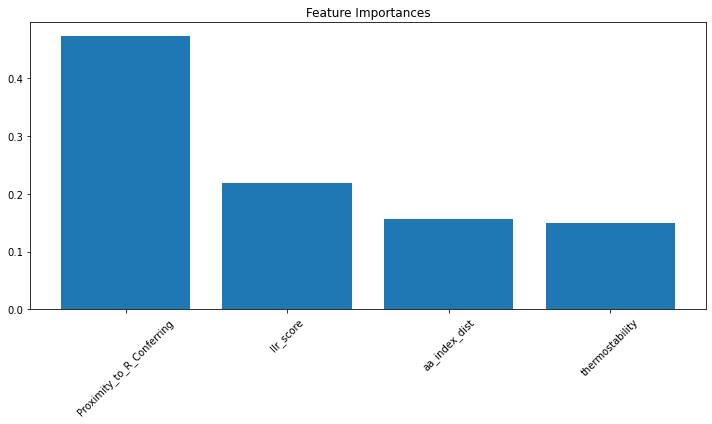

In [28]:
# Feature Importance
feature_importances = rf_classifier.feature_importances_
indices = np.argsort(feature_importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Feature Importances")
plt.bar(range(X_train_split.shape[1]), feature_importances[indices], align="center")
plt.xticks(range(X_train_split.shape[1]), [numeric_columns[i] for i in indices], rotation=45)
plt.tight_layout()
plt.show()

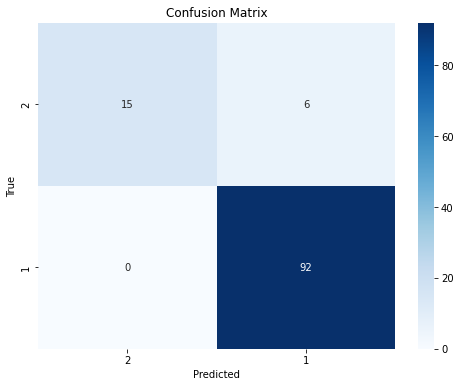

In [29]:
# Confusion Matrix Visualization
#categories = np.unique(np.concatenate([y_test_split, y_pred_split]))  
#plt.figure(figsize=(8, 6))
#sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=categories, yticklabels=categories)

cm = confusion_matrix(y_test_split, y_pred_split)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[2, 1 ], yticklabels=[2, 1 ])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [30]:
# ROC Curve
y_prob_split = rf_classifier.predict_proba(X_test_split)
unique_classes = sorted(np.unique(y_train_split))
fpr = {}
tpr = {}
roc_auc = {}
# Debugging output to understand the data structure
print("Unique classes:", unique_classes)
print("Number of prediction columns in y_prob_split:", y_prob_split.shape[1])
# Mapping class labels to zero-based indices
class_to_index = {cls: idx for idx, cls in enumerate(unique_classes)}

# Adjusting the ROC curve calculation
fpr = {}
tpr = {}
roc_auc = {}

for cls in unique_classes:
    # Using the mapping to get the correct column index from y_prob_split
    idx = class_to_index[cls]
    fpr[cls], tpr[cls], _ = roc_curve(y_test_split == cls, y_prob_split[:, idx])
    roc_auc[cls] = auc(fpr[cls], tpr[cls])
    print(cls, roc_auc[cls])


Unique classes: [0, 1]
Number of prediction columns in y_prob_split: 2
0 0.9133022774327123
1 0.9133022774327122


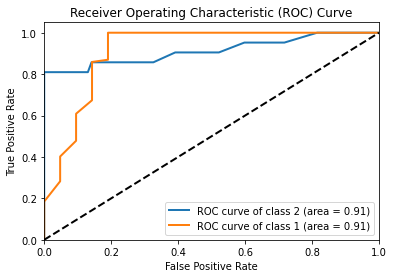

In [32]:
plt.figure()
for i in unique_classes:
    if i == 0:   
        plt.plot(fpr[i], tpr[i], lw=2, label='ROC curve of class 2 (area = {0:0.2f})'.format(roc_auc[i]))
    else:
        plt.plot(fpr[i], tpr[i], lw=2, label='ROC curve of class {0} (area = {1:0.2f})'.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()


In [33]:
## Natural Cubic Splines Basis Expansion: fit with four natural spline bases 

In [34]:
import statsmodels.api as sm
from scipy import stats
lr = sm.Logit( y_train_split, sm.add_constant(X_train_split)).fit(disp=False)
# simple logit regression will cause 'PerfectSeparationError: Perfect separation detected, results not available'
# so scaling the X is considered here
#lr = sm.Logit(y_label, sm.add_constant(StandardScaler().fit_transform(X_label)))

In [35]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from typing import List
class NaturalCubicSplineFeatures(BaseEstimator, TransformerMixin):
    """Generate natural cubic spline and interaction features.
    Parameters
    ----------
    knots :
        Is a list that contains knots list for each feature.
    add_interactions :
        If false, only natural cubic spline features are produced, otherwise
        expanded features interactions are included.
    target_dofs :
        Is a number of degrees of freedom for each feature. If is set, df+1
        knots for features would be automatically calculated at uniform
        quantiles including min and max value of a feature.
    Attributes
    ----------
    dofs_:
        The degrees of freedom for each feature.
    positions_:
        For each feature the index of the first and the last indices of its
        components."""
    def __init__(self, knots: List[List[float]]=None, target_dofs: int=None,
                 add_interactions: bool = False):
        self.knots = knots
        self.add_interactions = add_interactions
        self.target_dofs = target_dofs

    def fit(self, X: np.ndarray,
            y: np.array=None) -> 'NaturalCubicSplineFeatures':
        """Fit NaturalCubicSplineFeatures model according to the given training
           data and parameters.
        Parameters
        ----------
        X :
            Training data.
        y :
            Target values.
        """
        if self.target_dofs is not None:
            quantiles = np.linspace(0, 1, self.target_dofs + 1)
            self.knots = []
            for i in range(X.shape[1]):
                self.knots.append(np.unique(np.quantile(X[:, i], quantiles)))
        # calculate the number of parameters in each component term
        self.dofs_ = np.array([len(k)-1 for k in self.knots])
        # for each feature calculate the first and the last index of expanded
        # basis
        dofs_cumsum = [0] + list(np.cumsum(self.dofs_))
        self.positions_ = [(dofs_cumsum[i-1], dofs_cumsum[i]-1)
                           for i in range(1, len(dofs_cumsum))]
        return self

    def transform(self, X: np.ndarray) -> np.ndarray:
        """Transform data to natural cubic spline basis expansion
        Parameters
        ----------
        X :
            The data to transform, row by row
        Returns
        -------
        X_new : np.ndarray, shape [n_samples, NN]
            The matrix of features, where NN is the number of natural cubic
            spline features generated from the inputs based on knots.
        """
        features_basis_splines = []
        for i in range(X.shape[1]):
            features_basis_splines.append(
                self.__expand_natural_cubic(X[:, i:i+1], self.knots[i]))
        if self.add_interactions:
            self.__add_interaction_features(features_basis_splines)
        return np.hstack(features_basis_splines)

    @staticmethod
    def __dk(X: np.ndarray, knot: float, knot_last: float) -> np.ndarray:
        return (X - knot).clip(0) ** 3 / (knot_last - knot)

    @staticmethod
    def __expand_natural_cubic(X: np.ndarray, knots: np.array) -> np.ndarray:
        basis_splines = [X]
        dk_last = NaturalCubicSplineFeatures.__dk(X, knots[-2], knots[-1])
        for knot in knots[:-2]:
            dk = NaturalCubicSplineFeatures.__dk(X, knot, knots[-1])
            basis_splines.append(dk - dk_last)
        return np.hstack(basis_splines)

    @staticmethod
    def __add_interaction_features(features_basis_splines):
        features_indices = [list(range(expansion.shape[1]))
                            for expansion in features_basis_splines]
        for combination in itertools.product(*features_indices):
            product = features_basis_splines[0][:, combination[0]].copy()
            for i in range(1, len(combination)):
                product *= features_basis_splines[i][:, combination[i]]
            features_basis_splines.append(np.atleast_2d(product).T)

In [36]:
ncs_features = NaturalCubicSplineFeatures(target_dofs=3)
add_intercept = FunctionTransformer(
    lambda X: sm.add_constant(X_train_split), validate=True)
data_prep_pipeline = Pipeline([('scale_features', StandardScaler()),
                               ('expand_basis', ncs_features),
                               ('scale_basis', StandardScaler()),
                               ('add_intercept_column', add_intercept)])

In [37]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(
    solver='lbfgs', max_iter=100000, C=10e10, fit_intercept=False)
expanded_lr = Pipeline([('prepare', data_prep_pipeline),
                        ('logistic', lr)])

In [38]:
expanded_lr.fit(X_train_split, y_train_split)

print("Logistic Regression Coefficients:")
print(expanded_lr.named_steps['logistic'].coef_)

Logistic Regression Coefficients:
[[ 2.27324021 -1.9953643   0.46758856  0.39385107  1.19346089]]


In [39]:
# Transform the data to appropriate data struture
X_test_transformed = expanded_lr.named_steps['prepare'].transform(X_test_split)
print("Original shape:", X_test_split.shape)
print("Transformed shape:", X_test_transformed.shape)
 
ncs_features.fit(X_train_split)  
X_train_transformed = ncs_features.transform(X_train_split)
 
lr.fit(X_train_transformed, y_train_split)
print("Model Coefficients:", lr.coef_)

 
X_test_transformed = ncs_features.transform(X_test_split)
y_pred = lr.predict(X_test_transformed)
print("Predicted labels:", y_pred)


Original shape: (113, 4)
Transformed shape: (261, 5)
Model Coefficients: [[-1.34571437e+00 -2.46829544e+00 -1.39460998e+00  3.71672144e-01
   3.85947230e-03  3.72850225e-01 -8.21230783e-02  1.83615837e-01
  -1.96489822e+00 -1.57202470e+00  2.89395757e+01  1.05805780e+01]]
Predicted labels: [1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 0 1 1 1 1 1 1 0 1 1 0 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 1 0 1 0 1 1 0 1 1 0 1 1 1 0 1 1 1 1
 1 1 0 0 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 0 1 1 0
 1 1]


In [40]:
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
from matplotlib import transforms, pyplot as plt
import numpy as np

def error_rate(y_true, y_pred):
    return 1 - accuracy_score(y_true, y_pred)
# Calculate the accuracy
accuracy = accuracy_score(y_test_split, y_pred)
print("\nAccuracy:", accuracy)

# Give the Classification Report
print("\nClassification Report:")
print(classification_report(y_test_split, y_pred)) 

lr_error_rate = error_rate(y_test_split, y_pred)  
 
print(f'Logistic Regression Test Error Rate: {lr_error_rate*100:.1f}%')


Accuracy: 0.9380530973451328

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.76      0.82        21
           1       0.95      0.98      0.96        92

    accuracy                           0.94       113
   macro avg       0.92      0.87      0.89       113
weighted avg       0.94      0.94      0.94       113

Logistic Regression Test Error Rate: 6.2%


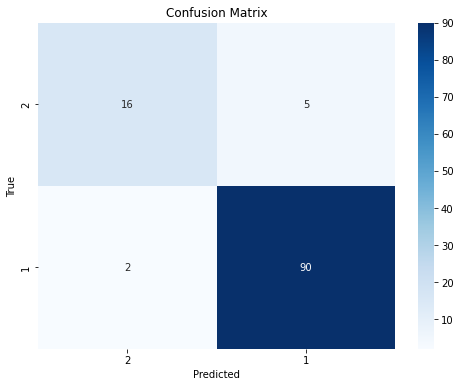

In [41]:
cm = confusion_matrix(y_test_split, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[2, 1], yticklabels=[2, 1])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

Unique classes: [0, 1]
Class 0 AUC: 0.88
Class 1 AUC: 0.88


<function matplotlib.pyplot.show(close=None, block=None)>

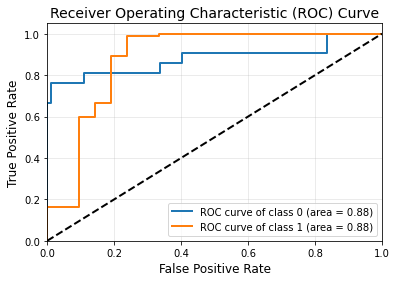

In [42]:
# Make prediction toward the test set using the natrual cubic spline regression
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Transform the test data and predict probabilities
X_test_transformed = ncs_features.transform(X_test_split)  # Transform the test data
y_prob_split = lr.predict_proba(X_test_transformed)  # Predicted probabilities

# Extract unique classes
unique_classes = sorted(np.unique(y_train_split))
print("Unique classes:", unique_classes)

# Initialize variables
class_to_index = {cls: idx for idx, cls in enumerate(unique_classes)}
fpr = {}
tpr = {}
roc_auc = {}

# Calculate ROC curve and AUC for each class
for cls in unique_classes:
    idx = class_to_index[cls]
    fpr[cls], tpr[cls], _ = roc_curve(y_test_split == cls, y_prob_split[:, idx])
    roc_auc[cls] = auc(fpr[cls], tpr[cls])
    print(f"Class {cls} AUC: {roc_auc[cls]:.2f}")

# Plot ROC curve
plt.figure()

for cls in unique_classes:
    plt.plot(fpr[cls], tpr[cls], lw=2, label=f"ROC curve of class {cls} (area = {roc_auc[cls]:0.2f})")

# Plot the diagonal line
plt.plot([0, 1], [0, 1], 'k--', lw=2)

# Formatting the plot
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14)
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.show


In [123]:
# # Natural cubic spilne(using splines pacakge)
# import patsy


In [124]:

# feature_names = ['Proximity_to_R_Conferring', 'aa_index_dist', 'llr_score', 'thermostability']

# X_train_df = pd.DataFrame(X_train_split, columns=feature_names)
# X_test_df = pd.DataFrame(X_test_split, columns=feature_names)
# #Use patsy to generate natural spline basis for training and test sets
# formula = (
#     "bs(Proximity_to_R_Conferring, df=8, include_intercept=False) + "
#     "bs(aa_index_dist, df=8, include_intercept=False) + "
#     "bs(llr_score, df=8, include_intercept=False) + "
#     "bs(thermostability, df=8, include_intercept=False)"
# )
# #Generate the natural spline design matrix for the training set
# X_train_spline = patsy.dmatrix(formula, data=X_train_df, return_type='dataframe')
# X_test_spline = patsy.dmatrix(formula, data=X_test_df, return_type='dataframe')

# model = LogisticRegression()
# model.fit(X_train_spline, y_train_split)
# y_pred = model.predict(X_test_spline)
# print(classification_report(y_test_split, y_pred))
# print("Model Coefficients:\n", model.coef_)
# print(accuracy_score(y_test_split, y_pred))

In [45]:
## Generalized Additive Model

In [46]:
import pandas as pd
from matplotlib import transforms, pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score

def error_rate(y_true, y_pred):
    return 1 - accuracy_score(y_true, y_pred)

In [47]:
lr_clf = sm.Logit(y_train_split, sm.add_constant(X_train_split)).fit(disp=False)
# 0.5 is a threshold
y_test_hat = (lr_clf.predict(sm.add_constant(X_test_split)) > 0.5).astype(int)
lr_error_rate = error_rate(y_test_split, y_test_hat) 
print(f'Logistic Regression Test Error Rate: {lr_error_rate*100:.1f}%') # it is 6.2%, for later comparism

Logistic Regression Test Error Rate: 6.2%


In [48]:
#!pip install pygam
from pygam import LogisticGAM
from sklearn.metrics import confusion_matrix

In [49]:
lam = np.array([1.00e+06, 5.00e+02, 5.00e+02, 1.00e-01])                               # 56-57

In [50]:
#X_train_log = np.log(X_train_split)
#X_test_log = np.log(X_test_split)
#gam_clf = LogisticGAM(lam=lam).fit(X_train_log, y_train_split)
gam_clf = LogisticGAM(lam=lam).fit(X_train_split, y_train_split)

/Users/wangyu/opt/anaconda3/lib/python3.9/site-packages/pygam/links.py:149: RuntimeWarning: divide by zero encountered in divide
  return dist.levels / (mu * (dist.levels - mu))
/Users/wangyu/opt/anaconda3/lib/python3.9/site-packages/pygam/pygam.py:627: RuntimeWarning: invalid value encountered in multiply
  self.link.gradient(mu, self.distribution) ** 2


In [51]:
y_test_proba = gam_clf.predict_proba(X_test_split)
 
custom_threshold = 0.5
y_test_pred = (y_test_proba >= custom_threshold).astype(int)
print("Predicted Classes:", y_test_pred[:10]) 
accuracy = accuracy_score(y_test_split, y_test_pred)
#print the prediction result
print(y_test_pred)

Predicted Classes: [1 1 1 1 1 1 0 1 1 1]
[1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 0 1 1 1 1 1 1 0 1 1 0 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 1 0 1 0 1 1 0 1 1 0 1 1 1 0 1 1 1 1
 1 1 0 0 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 0
 1 1]


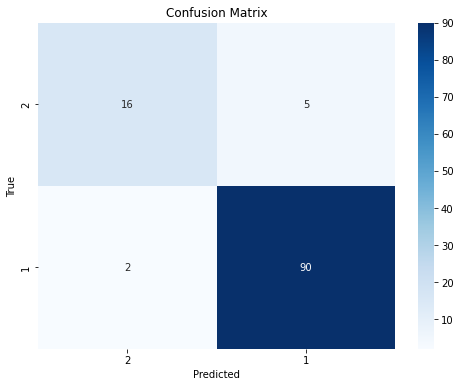

In [52]:
cm = confusion_matrix(y_test_split, y_test_pred )
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[2, 1], yticklabels=[2, 1])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [53]:
 # accuracy
accuracy = accuracy_score(y_test_split,y_test_hat)
print("\nAccuracy:", accuracy)

# Classification
print("\nClassification Report:")
print(classification_report(y_test_split, y_test_hat))
lr_error_rate = error_rate(y_test_split, y_test_hat)
 
print(f'Logistic Regression Test Error Rate: {lr_error_rate*100:.1f}%')


Accuracy: 0.9380530973451328

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.76      0.82        21
           1       0.95      0.98      0.96        92

    accuracy                           0.94       113
   macro avg       0.92      0.87      0.89       113
weighted avg       0.94      0.94      0.94       113

Logistic Regression Test Error Rate: 6.2%


Some note on December:
On the 2021 dataset, the Generalized Additive Model will have a better result(Accuracy: 0.94),Natural Cubic Splines with four spline basis have 0,93 accuracy. GAQQ's accuracy is 0.87. And all of them use the default setting. Result may change with different setting. So my next goal is select the number of spline basis for spline model, and chose the lambda for both GAM and GAQQ.

One things is that the train data might be different ,they are in differnet sofrware.

increase to 5?

Mars  interaction
 


In [54]:
#Multivariate Adaptive Regression Splines (MARS)
import rpy2.robjects as ro
from rpy2.robjects.packages import importr
from rpy2.robjects import pandas2ri

# activate transform between pandas and R  
pandas2ri.activate()

# import r package 
base = importr('base')
utils = importr('utils')
earth = importr('earth')
 


In [55]:
# try several degree for MARS
mars_model = earth.earth(X_train_split, y_train_split ,degree =2) #when degree=2, it will have high acc
#It is best not to have a high degree, as a high degree will lead to a lack of interpretability.

# use predict() function in R to predict
predict = ro.r['predict']  # loading predict() from R
y_pred_r = predict(mars_model, X_test_split, type = "class")  # prediction

# transform matrix(in R) to numpy 
y_test_pred = np.array(y_pred_r) 
 
# Calculate the accuracy
accuracy_score(y_test_split, y_test_pred)
print(accuracy_score(y_test_split, y_test_pred))

0.9557522123893806


In [56]:
summary = ro.r['summary']
model_summary = summary(mars_model)
print(model_summary)

Call: earth(x=matrix[261,4], y=c(1,1,0,1,1,1,1...), degree=2)

                                    coefficients
(Intercept)                           -0.2013973
h(1.7181-x1)                           0.4719331
h(-0.498322-x2)                        1.7870084
h(x2- -0.498322)                       0.7341175
h(-1.53006-x3)                         0.2277046
h(x1- -0.232214) * h(x2- -0.498322)   -0.1484601
h(-0.230151-x1) * h(-0.498322-x2)     -1.6998836
h(1.7181-x1) * h(x2- -0.263194)       -0.3362587
h(-0.597563-x2) * h(x3- -1.53006)     -0.8083887
h(-0.498322-x2) * h(0.114414-x3)      -1.1758465
h(x2- -0.498322) * h(-0.538865-x3)    -0.1685551

Selected 11 of 20 terms, and 3 of 4 predictors
Termination condition: Reached nk 21
Importance: x1, x2, x3, x4-unused
Number of terms at each degree of interaction: 1 4 6
GCV 0.0824967    RSS 17.45548    GRSq 0.3418956    RSq 0.4623696



              precision    recall  f1-score   support

           0       0.94      0.81      0.87        21
           1       0.96      0.99      0.97        92

    accuracy                           0.96       113
   macro avg       0.95      0.90      0.92       113
weighted avg       0.96      0.96      0.95       113



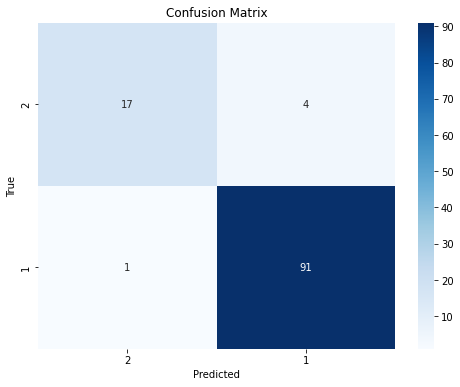

In [57]:
print(classification_report(y_test_split, y_test_pred))
cm = confusion_matrix(y_test_split, y_test_pred )
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[2, 1], yticklabels=[2, 1])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

Unique classes: [0, 1]
Class 0 AUC: 0.90
Class 1 AUC: 0.90


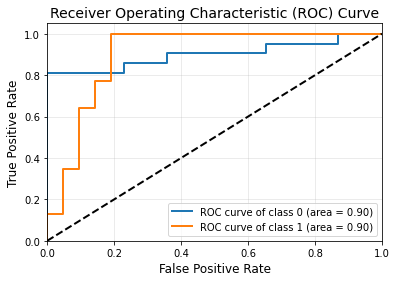

In [58]:
# use the predic function in R on the mars model
predict = ro.r['predict'] # use predict function in R
# use mars to predict
y_pred_response = np.array(predict(mars_model, X_test_split, type="response"))
 
y_prob_split = np.column_stack([1 - y_pred_response, y_pred_response])

# transform into numpy
y_pred_r = predict(mars_model, X_test_split, type="class")  
 

unique_classes = sorted(np.unique(y_train_split))
print("Unique classes:", unique_classes)

class_to_index = {cls: idx for idx, cls in enumerate(unique_classes)}
fpr = {}
tpr = {}
roc_auc = {}

# calculate roc and auc for each category  
for cls in unique_classes:
    idx = class_to_index[cls]
    fpr[cls], tpr[cls], _ = roc_curve(y_test_split == cls, y_prob_split[:, idx])
    roc_auc[cls] = auc(fpr[cls], tpr[cls])
    print(f"Class {cls} AUC: {roc_auc[cls]:.2f}")

# roc figure
plt.figure()

for cls in unique_classes:
    plt.plot(fpr[cls], tpr[cls], lw=2, label=f"ROC curve of class {cls} (area = {roc_auc[cls]:0.2f})")

 
plt.plot([0, 1], [0, 1], 'k--', lw=2)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14)
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.show()

In [59]:
# from pyearth import Earth
# # Combine Earth with LogisticRegression in a pipeline to do classification
# earth_classifier = Pipeline(
#     [('earth', Earth()),
#      ('logistic', LogisticRegression(solver='lbfgs'))]
# ).fit(X_train_log, y_train)

In [60]:
# # Combine Earth with LogisticRegression in a pipeline to do classification
# earth_classifier = Pipeline(
#     [('earth', Earth()),
#      ('logistic', LogisticRegression(solver='lbfgs'))]
# ).fit(X_train_split, y_train_split)

In [61]:
#GAQQ

In [62]:
# frequency = label_data.loc[:, 'frequency']
# scaler_freq = StandardScaler()
# frequency_scaled = scaler_freq.fit_transform(frequency.values.reshape(-1, 1))
# X_train_split, X_test_split, y_train_split, y_test_split, frequency_train, frequency_test = train_test_split(
#     X_scaled, y_label, frequency_scaled, test_size=0.3, random_state=42
# )
# #print(X_train_split)
# #print(X_train_split1)
# X_train_split.shape
# frequency_train.shape

# indices1 = np.where(y_train_split == 1)[0]
# X_selected1 = X_train_split[indices1]
# frequency_selected1 = frequency_train[indices1]
# X1 = np.hstack((X_selected1, frequency_selected1.reshape(-1, 1)))

# indices0 = np.where(y_train_split == 0)[0]
# X_selected0 = X_train_split[indices0]
# frequency_selected0 = frequency_train[indices0]
# X2 = np.hstack((X_selected0, frequency_selected0.reshape(-1, 1)))

# indices1 = np.where(y_test_split == 1)[0]
# X_selected1 = X_test_split[indices1]
# frequency_selected1 = frequency_test[indices1]
# X3 = np.hstack((X_selected1, frequency_selected1.reshape(-1, 1)))

# indices0 = np.where(y_test_split == 0)[0]
# X_selected0 = X_test_split[indices0]
# frequency_selected0 = frequency_test[indices0]
# X4 = np.hstack((X_selected0, frequency_selected0.reshape(-1, 1)))

In [63]:
# #X1 = X_train_split[y_train_split == 1]
# #X2 = X_train_split[y_train_split == 0]
# #X3 = X_test_split[y_test_split == 1]
# #X4 = X_test_split[y_test_split == 0]
# lambda1 = np.linspace(0.02, 5, 50)
# lambda2 = np.linspace(0.01, 5, 50)
# X1.shape
# X2.shape
# print(X1)

[[ 2.91325965e-01 -1.42676216e+00  7.86078136e-02 -3.51829145e-01
   1.57318054e-03]
 [-4.11663308e-01 -1.12695527e+00 -3.09539420e-01 -4.63061295e-01
   7.76208307e-01]
 [-4.09141045e-01  5.57110582e-01  3.18777956e-01 -4.57121854e-01
  -6.64613028e-01]
 ...
 [-2.60343294e-01 -1.01985338e+00 -3.14368526e-01  1.53159058e+00
   7.76208307e-01]
 [-4.11536578e-01  1.11502252e+00  4.52661089e-01 -4.17636707e-01
  -8.82844942e-02]
 [-2.57103630e-01  1.10317178e-01  1.66683390e+00 -4.63007457e-01
   7.76208307e-01]]


In [66]:
# import rpy2.robjects as ro
# from rpy2.robjects import pandas2ri
 
# pandas2ri.activate()
 
# r = ro.r
# try:
#     r['source']("/Users/wangyu/Desktop/Kang/Robust_Regression/est.twoclass.R")
#     print("R script loaded successfully.")
# except Exception as e:
#     print(f"Error loading R script: {e}")


In [67]:
# def check_invalid_values(matrix, name):
#     if np.any(np.isnan(matrix)):
#         print(f"{name} contains NaN values.")
#     if np.any(np.isinf(matrix)):
#         print(f"{name} contains Inf values.")
#     if not np.any(np.isnan(matrix)) and not np.any(np.isinf(matrix)):
#         print(f"{name} is free from NaN and Inf values.")

# check_invalid_values(X1, "X1")
# check_invalid_values(X2, "X2")

# SLDA_EBIC = ro.globalenv['SLDA.EBIC']
# classify = ro.globalenv['classify']
# lambda1 = np.linspace(0.01, 1, 100)
# lambda2 = np.linspace(0.01, 10, 100)

# result = SLDA_EBIC(X1, X2, lambda1, lambda2)
# C_opt = np.array(result.rx2('C_opt'))  # get C_opt
# print("Type of C_opt:", type(C_opt))
# print("C_opt matrix:")
# print(C_opt)
# print("Condition number:", np.linalg.cond(C_opt))

# #

# #pred_result = classify(X1, X2, X3, X4, np.corrcoef(C_opt), delta_h_opt)

In [68]:
# delta_h_opt = result.rx2('delta_h_opt')
# print(delta_h_opt)

In [69]:
# epsilon = 1e-8  # use this to avoid singular
# C_opt_regularized = C_opt + epsilon * np.eye(C_opt.shape[0])
# C_opt_r = ro.r.matrix(C_opt_regularized, nrow=C_opt_regularized.shape[0], ncol=C_opt_regularized.shape[1])
# ro.globalenv['C_opt'] = C_opt_r

# # run classify function
# try:
#     pred_result = classify(X1, X2, X3, X4, C_opt_r, delta_h_opt)
#     print("Classify completed successfully.")
# except Exception as e:
#     print(f"Error during classify with regularized C_opt: {e}")

# y_hat = np.array(pred_result.rx2('y_hat'))
# error = pred_result.rx2('error')[0]
# rmse = pred_result.rx2('rmse')[0]
# est_label = np.array(pred_result.rx2('est_label'))


In [71]:
# classify(X1, X2, X3, X4, C_opt_r, delta_h_opt)


In [72]:
# # cuaculate the classification result
# y_pred = 1 - est_label
# correct_predictions = y_pred == y_test_split
# accuracy = np.mean(correct_predictions)
# print(accuracy)

In [73]:
# cm = confusion_matrix(y_test_split, y_pred )
# plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[2, 1], yticklabels=[2, 1])
# plt.xlabel("Predicted")
# plt.ylabel("True")
# plt.title("Confusion Matrix")
# plt.show()

In [74]:
# print(classification_report(y_test_split, y_pred ))

find the difference between 2023 and 2021

In [75]:
# get the data for the 2023
catalog_df=pd.read_csv("/Users/wangyu/Desktop/Kang/Antibiotic resistance Forcast/resistance_forecast-main/data/derived_features/all_proteins_freq_details_proximity_aaindex_llr.csv")


all_gene_data = []
# Group the catalog by gene to process mutations per gene
for gene_name, gene_subset in catalog_df.groupby('gene'):
    print("Calculating for gene:", gene_name)
    
    # Sort the subset by position
    gene_subset = gene_subset.sort_values(by='position', ascending=True)
    # Load the Rosetta score CSV
    if gene_name=='gyrA':
        # Define file paths for N-terminal and C-terminal
        nter_file_path = f'/Users/wangyu/Desktop/Kang/Antibiotic resistance Forcast/resistance_forecast-main/data/Rosetta/{gene_name}_Nter_ddG.csv'
        cter_file_path = f'/Users/wangyu/Desktop/Kang/Antibiotic resistance Forcast/resistance_forecast-main/data/Rosetta/{gene_name}_Cter_ddG.csv'
        # Load the two parts
        nter_df = pd.read_csv(nter_file_path)
        cter_df = pd.read_csv(cter_file_path)
        # Concatenate the two DataFrames
        rosetta_scores= pd.concat([nter_df, cter_df], ignore_index=True)
    else:
        rosetta_scores_path = f'/Users/wangyu/Desktop/Kang/Antibiotic resistance Forcast/resistance_forecast-main/data/Rosetta/{gene_name}_ddG.csv' 
        rosetta_scores = pd.read_csv(rosetta_scores_path)
    rosetta_scores['Wildtype_AA'] = rosetta_scores['variant'].str.extract(r'([a-zA-Z])(?=\d)')
    rosetta_scores['position'] = rosetta_scores['variant'].str.extract(r'(\d+)').astype(int)
    rosetta_scores['Mutated_AA'] = rosetta_scores['variant'].str.extract(r'(?<=\d)([a-zA-Z])')
    # Merge the dataframes on Adjusted_Number and One_Letter
    common_data = pd.merge(
        rosetta_scores,
        gene_subset,
        left_on=['Wildtype_AA', 'position','Mutated_AA'],
        right_on=['Wildtype_AA', 'position','Mutated_AA'],
        how='inner'
        )
    common_data=common_data.drop(columns=['fa_atr', 'fa_rep', 'fa_sol', 'fa_intra_rep', 'fa_intra_sol_xover4',
       'lk_ball_wtd', 'fa_elec', 'pro_close', 'hbond_sr_bb', 'hbond_lr_bb',
       'hbond_bb_sc', 'hbond_sc', 'dslf_fa13', 'omega', 'fa_dun', 'p_aa_pp',
       'yhh_planarity', 'ref', 'rama_prepro','variant'])
    common_data=common_data.rename(columns={"score": "thermostability"})
    cols = ['gene'] + [col for col in common_data.columns if col != 'gene']
    common_data = common_data[cols]
    common_data.to_csv(f'/Users/wangyu/Desktop/Kang/Antibiotic resistance Forcast/resistance_forecast-main/data/derived_features/{gene_name}_thermostability.csv', index=False)
    all_gene_data.append(common_data)
    

Calculating for gene: Rv0678
Calculating for gene: atpE
Calculating for gene: ddn
Calculating for gene: embB
Calculating for gene: ethA
Calculating for gene: fgd1
Calculating for gene: gid
Calculating for gene: gyrA
Calculating for gene: gyrB
Calculating for gene: inhA
Calculating for gene: katG
Calculating for gene: pepQ
Calculating for gene: pncA
Calculating for gene: rplC
Calculating for gene: rpoB
Calculating for gene: rpsL
Calculating for gene: tlyA


In [76]:
# After the loop, concatenate all the DataFrames in the list into a single large DataFrame
final_df = pd.concat(all_gene_data, ignore_index=True)
final_df.to_csv("/Users/wangyu/Desktop/Kang/Antibiotic resistance Forcast/resistance_forecast-main/data/derived_features/all_proteins_freq_details_proximity_aaindex_thermostabilit.csv",index=False)

In [77]:
from IPython.display import display

In [78]:
import pandas as pd

# Load the 2021 and 2023 datasets
file_2021 = "/Users/wangyu/Desktop/Kang/Antibiotic resistance Forcast/resistance_forecast-main/data/derived_features/2021/2021_all_proteins_freq_details_proximity_aaindex_thermostability.csv"
file_2023 = "/Users/wangyu/Desktop/Kang/Antibiotic resistance Forcast/resistance_forecast-main/data/derived_features/all_proteins_freq_details_proximity_aaindex_thermostabilit.csv"

df_2021 = pd.read_csv(file_2021)
df_2023 = pd.read_csv(file_2023)



In [79]:
# Merge the two datasets on gene, Wildtype_AA, position, Mutated_AA
merged_df = pd.merge(
    df_2021,
    df_2023,
    on=['gene', 'one_letter_mutation'],
    suffixes=('_2021', '_2023')
)
merged_df=merged_df.drop_duplicates()

In [80]:

# Filter rows where confidence remained unchanged in category 3
unchanged_category_3 = merged_df[
    (merged_df['confidence_2021'] == "3) Uncertain significance") &
    (merged_df['confidence_2023'] == "3) Uncertain significance")
]
unchanged_category_3 = unchanged_category_3.drop_duplicates()

# Count the number of positions where the confidence remained unchanged
num_unchanged = unchanged_category_3.shape[0]

print(f"Number of positions where confidence remained unchanged in category 3: {num_unchanged}")

# Optionally, preview the unchanged rows
display(unchanged_category_3[['gene', 'one_letter_mutation', 'confidence_2021', 'confidence_2023']])

Number of positions where confidence remained unchanged in category 3: 5164


,gene,one_letter_mutation,confidence_2021,confidence_2023
0,Rv0678,S2I,3) Uncertain significance,3) Uncertain significance
1,Rv0678,S2I,3) Uncertain significance,3) Uncertain significance
2,Rv0678,S2I,3) Uncertain significance,3) Uncertain significance
3,Rv0678,S2I,3) Uncertain significance,3) Uncertain significance
4,Rv0678,S2R,3) Uncertain significance,3) Uncertain significance
...,...,...,...,...
5693,tlyA,R244P,3) Uncertain significance,3) Uncertain significance
5694,tlyA,A250T,3) Uncertain significance,3) Uncertain significance
5695,tlyA,R249Q,3) Uncertain significance,3) Uncertain significance
5696,tlyA,S252L,3) Uncertain significance,3) Uncertain significance


In [81]:
# Exclude rows where confidence is "3) Uncertain significance" in both files
filtered_df = merged_df[
    ~((merged_df['confidence_2021'] == "3) Uncertain significance") &
      (merged_df['confidence_2023'] == "3) Uncertain significance"))
]

# Identify rows where confidence values differ between 2021 and 2023
updated_confidence = filtered_df[
    filtered_df['confidence_2021'] != filtered_df['confidence_2023']
]

In [82]:
print(merged_df.shape,filtered_df.shape,updated_confidence.shape)

(5698, 28) (534, 28) (169, 28)


In [83]:
filtered_df=filtered_df.drop_duplicates()

In [84]:
filtered_df['confidence_2021'].value_counts()

1) Assoc w R                  170
2) Assoc w R - Interim        169
3) Uncertain significance     111
5) Not assoc w R               59
4) Not assoc w R - Interim     25
Name: confidence_2021, dtype: int64

In [85]:
filtered_df['confidence_2023'].value_counts()

2) Assoc w R - Interim        220
1) Assoc w R                  207
5) Not assoc w R               65
4) Not assoc w R - Interim     25
3) Uncertain significance      17
Name: confidence_2023, dtype: int64

In [86]:
# Check for rows where confidence is 3 in both 2021 and 2023
confidence_3_in_both = filtered_df[
    (filtered_df['confidence_2021'] == "3) Uncertain significance") &
    (filtered_df['confidence_2023'] == "3) Uncertain significance")
]

# Display the result
print(f"Number of rows with confidence 3 in both 2021 and 2023: {confidence_3_in_both.shape[0]}")
print(confidence_3_in_both)

Number of rows with confidence 3 in both 2021 and 2023: 0
Empty DataFrame
Columns: [gene, thermostability_2021, Wildtype_AA_2021, position_2021, Mutated_AA_2021, one_letter_mutation, drug_2021, confidence_2021, delta_z_2021, frequency_2021, phenotype_2021, Proximity_to_R_Conferring_2021, Nearest_Mutation_Index_2021, aa_index_dist_2021, llr_score_2021, thermostability_2023, Wildtype_AA_2023, position_2023, Mutated_AA_2023, drug_2023, confidence_2023, delta_z_2023, frequency_2023, phenotype_2023, Proximity_to_R_Conferring_2023, Nearest_Mutation_Index_2023, aa_index_dist_2023, llr_score_2023]
Index: []

[0 rows x 28 columns]


In [87]:
# Filter for confidence_2021 == "3) Uncertain significance" that changed to other categories
confidence_3_changed = filtered_df[
    (filtered_df['confidence_2021'] == "3) Uncertain significance") &
    (filtered_df['confidence_2023'] != "3) Uncertain significance")
]
confidence_3_changed = confidence_3_changed.drop_duplicates(subset=['gene', 'one_letter_mutation','confidence_2021','confidence_2023'])
# Count value occurrences in confidence_2023
changed_counts = confidence_3_changed['confidence_2023'].value_counts()

# Display the result
print(f"Number of mutations with confidence 3 in 2021 that changed to other categories in 2023: {confidence_3_changed.shape[0]}")
print("Value counts of the changed categories in 2023:")
print(changed_counts)

Number of mutations with confidence 3 in 2021 that changed to other categories in 2023: 81
Value counts of the changed categories in 2023:
2) Assoc w R - Interim        55
1) Assoc w R                  15
5) Not assoc w R               6
4) Not assoc w R - Interim     5
Name: confidence_2023, dtype: int64


In [88]:

confidence_3_changed[['gene', 'one_letter_mutation','confidence_2021', 'confidence_2023']].to_csv("/Users/wangyu/Desktop/Kang/Antibiotic resistance Forcast/resistance_forecast-main/data/common_mutations_category_update_from21to23.csv",index=False)

In [89]:
confidence_3_changed

,gene,thermostability_2021,Wildtype_AA_2021,position_2021,Mutated_AA_2021,one_letter_mutation,drug_2021,confidence_2021,delta_z_2021,frequency_2021,...,Mutated_AA_2023,drug_2023,confidence_2023,delta_z_2023,frequency_2023,phenotype_2023,Proximity_to_R_Conferring_2023,Nearest_Mutation_Index_2023,aa_index_dist_2023,llr_score_2023
57,Rv0678,4.401591,L,32,S,L32S,BDQ,3) Uncertain significance,0.147523,0.000000,...,S,Bedaquiline,2) Assoc w R - Interim,0.147523,0.833333,Resistant,2.799001,36.0,37.326490,5.877594
61,Rv0678,42.607373,A,36,V,A36V,CFZ,3) Uncertain significance,0.107635,0.000000,...,V,Bedaquiline,2) Assoc w R - Interim,0.107635,1.000000,Resistant,2.799001,32.0,27.720968,-5.190504
82,Rv0678,115.069636,C,46,R,C46R,BDQ,3) Uncertain significance,0.222652,0.000000,...,R,Clofazimine,2) Assoc w R - Interim,0.222652,1.000000,Resistant,7.195753,36.0,40.517919,4.639270
134,Rv0678,0.549397,N,70,D,N70D,BDQ,3) Uncertain significance,0.122702,0.000000,...,D,Bedaquiline,2) Assoc w R - Interim,0.122702,0.857143,Resistant,3.117993,67.0,20.632582,-3.783930
136,Rv0678,7.209093,I,67,S,I67S,BDQ,3) Uncertain significance,0.178202,1.000000,...,S,Bedaquiline,2) Assoc w R - Interim,0.178202,1.000000,Resistant,3.117993,70.0,38.250585,8.924705
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4970,pncA,7.673205,L,159,V,L159V,PZA,3) Uncertain significance,0.052354,0.500000,...,V,Pyrazinamide,2) Assoc w R - Interim,0.052354,0.600000,Resistant,1.330143,160.0,21.748474,4.245023
4972,pncA,5.972033,T,160,A,T160A,PZA,3) Uncertain significance,0.058989,1.000000,...,A,Pyrazinamide,4) Not assoc w R - Interim,0.058988,0.571429,Susceptible,1.330143,159.0,26.416943,4.286821
4978,pncA,0.657171,V,163,A,V163A,PZA,3) Uncertain significance,0.053480,0.000000,...,A,Pyrazinamide,2) Assoc w R - Interim,0.053480,0.750000,Resistant,1.326742,162.0,27.720968,2.453124
4991,pncA,47.527063,M,175,I,M175I,PZA,3) Uncertain significance,0.069766,0.333333,...,I,Pyrazinamide,2) Assoc w R - Interim,0.069766,0.500000,Resistant,3.468004,177.0,24.487350,0.459367


In [90]:
print(confidence_3_changed['confidence_2021'].unique())
print(confidence_3_changed['confidence_2023'].unique())


['3) Uncertain significance']
['2) Assoc w R - Interim' '1) Assoc w R' '5) Not assoc w R'
 '4) Not assoc w R - Interim']


In [91]:
# Convert the target var 
 

mapping = {
    "1) Assoc w R": 1,
    "2) Assoc w R - Interim": 1,
    "4) Not assoc w R - Interim": 0,
    "5) Not assoc w R": 0,
}

confidence_3_changed['confidence_2023'] = confidence_3_changed['confidence_2023'].map(mapping)

print(confidence_3_changed[['confidence_2021', 'confidence_2023']])
print(confidence_3_changed['confidence_2023'].unique())

                confidence_2021  confidence_2023
57    3) Uncertain significance                1
61    3) Uncertain significance                1
82    3) Uncertain significance                1
134   3) Uncertain significance                1
136   3) Uncertain significance                1
...                         ...              ...
4970  3) Uncertain significance                1
4972  3) Uncertain significance                0
4978  3) Uncertain significance                1
4991  3) Uncertain significance                1
4993  3) Uncertain significance                1

[81 rows x 2 columns]
[1 0]


In [92]:
# random forerest prediction

In [93]:
# Step 0: Remove duplicates from both DataFrames
catalog_data = catalog_data.drop_duplicates(subset=['gene', 'one_letter_mutation','confidence'])
# confidence_3_changed = confidence_3_changed.drop_duplicates(subset=['gene', 'one_letter_mutation'])

# Step 1: Select mutation positions from confidence_3_changed
selected_positions = confidence_3_changed[['gene', 'one_letter_mutation', 'confidence_2023']]

# Step 2: Filter category_3_data to match the selected positions
category_3_data = catalog_data[catalog_data['confidence'] == "3) Uncertain significance"]
category_3_data = category_3_data.merge(selected_positions, on=['gene', 'one_letter_mutation'], how='inner')

# Check the shape
print(f"Shape of filtered category_3_data after dropping duplicates: {category_3_data.shape}")

Shape of filtered category_3_data after dropping duplicates: (81, 16)


In [94]:
# Step 1: Select mutation positions from confidence_3_changed (use one_letter_mutation_2021)
selected_positions = confidence_3_changed[['gene', 'one_letter_mutation', 'confidence_2023']]
# Step 2: Filter category_3_data to match the selected positions
category_3_data = catalog_data[catalog_data['confidence'] == "3) Uncertain significance"]
category_3_data = category_3_data.merge(selected_positions, on=['gene', 'one_letter_mutation'], how='inner')
# category_3_data = category_3_data.drop_duplicates()

In [95]:
category_3_data.shape

(81, 16)

In [96]:
# Step 3: Prepare data for prediction
category_3_data[numeric_columns] = category_3_data[numeric_columns].fillna(0)  # Handle missing values
X_category_3 = category_3_data[numeric_columns]




In [97]:
print(X_category_3)

    Proximity_to_R_Conferring  aa_index_dist  llr_score  thermostability
0                    0.000000      37.326490   5.877594         4.401591
1                    0.000000      27.720968  -5.190506        42.607373
2                    0.000000      40.517919   4.639273       115.069636
3                    0.000000      20.632582  -3.783928         0.549397
4                    0.000000      38.250585   8.924705         7.209093
..                        ...            ...        ...              ...
76                   1.330143      21.748474   4.245020         7.673205
77                   1.330143      26.416943   4.286824         5.972033
78                   1.326742      27.720968   2.453126         0.657171
79                   3.468004      24.487350   0.459368        47.527063
80                   3.468004      36.690039   5.420083        68.498923

[81 rows x 4 columns]


In [98]:
# Step 4: Make predictions for the filtered data
category_3_data['predicted_confidence'] = rf_classifier.predict(X_category_3)
category_3_data['predicted_confidence'] = rf_classifier.predict(category_3_data[features].to_numpy())

/Users/wangyu/opt/anaconda3/lib/python3.9/site-packages/sklearn/base.py:443: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [99]:
category_3_data

,gene,thermostability,Wildtype_AA,position,Mutated_AA,one_letter_mutation,drug,confidence,delta_z,frequency,phenotype,Proximity_to_R_Conferring,Nearest_Mutation_Index,aa_index_dist,llr_score,confidence_2023,predicted_confidence
0,Rv0678,4.401591,L,32,S,L32S,BDQ,3) Uncertain significance,0.147523,0.000000,Unknown,0.000000,NaN,37.326490,5.877594,1,1
1,Rv0678,42.607373,A,36,V,A36V,CFZ,3) Uncertain significance,0.107635,0.000000,Unknown,0.000000,NaN,27.720968,-5.190506,1,1
2,Rv0678,115.069636,C,46,R,C46R,BDQ,3) Uncertain significance,0.222652,0.000000,Unknown,0.000000,NaN,40.517919,4.639273,1,1
3,Rv0678,0.549397,N,70,D,N70D,BDQ,3) Uncertain significance,0.122702,0.000000,Unknown,0.000000,NaN,20.632582,-3.783928,1,1
4,Rv0678,7.209093,I,67,S,I67S,BDQ,3) Uncertain significance,0.178202,1.000000,Unknown,0.000000,NaN,38.250585,8.924705,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76,pncA,7.673205,L,159,V,L159V,PZA,3) Uncertain significance,0.052354,0.500000,Unknown,1.330143,160.0,21.748474,4.245020,1,1
77,pncA,5.972033,T,160,A,T160A,PZA,3) Uncertain significance,0.058989,1.000000,Unknown,1.330143,159.0,26.416943,4.286824,0,1
78,pncA,0.657171,V,163,A,V163A,PZA,3) Uncertain significance,0.053480,0.000000,Unknown,1.326742,162.0,27.720968,2.453126,1,1
79,pncA,47.527063,M,175,I,M175I,PZA,3) Uncertain significance,0.069766,0.333333,Unknown,3.468004,177.0,24.487350,0.459368,1,0


In [100]:
# Step 5: Update catalog_data with the predictions
catalog_data.loc[
    catalog_data['confidence'] == "3) Uncertain significance", 
    'predicted_confidence'
] = category_3_data['predicted_confidence']

In [101]:
# Step 6: Print predictions alongside confidence_2023 for comparison
# Display the DataFrame in a clear format

print("Predicted Confidence vs Confidence 2023:")
display(category_3_data[['gene', 'one_letter_mutation', 'predicted_confidence', 'confidence_2023']])

Predicted Confidence vs Confidence 2023:


,gene,one_letter_mutation,predicted_confidence,confidence_2023
0,Rv0678,L32S,1,1
1,Rv0678,A36V,1,1
2,Rv0678,C46R,1,1
3,Rv0678,N70D,1,1
4,Rv0678,I67S,1,1
...,...,...,...,...
76,pncA,L159V,1,1
77,pncA,T160A,1,0
78,pncA,V163A,1,1
79,pncA,M175I,0,1


In [102]:
category_3_data.to_csv("/Users/wangyu/Desktop/Kang/Antibiotic resistance Forcast/resistance_forecast-main/data/model_pred_on2023_data.csv",index=False)

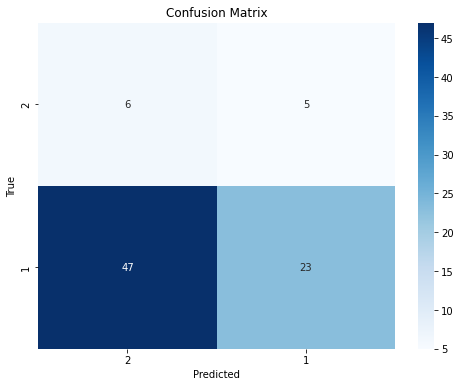

In [103]:
cm = confusion_matrix(category_3_data['confidence_2023'], category_3_data['predicted_confidence'])
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[2, 1], yticklabels=[2, 1])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


In [104]:
print(classification_report(category_3_data['confidence_2023'], category_3_data['predicted_confidence'] ))

              precision    recall  f1-score   support

           0       0.11      0.55      0.19        11
           1       0.82      0.33      0.47        70

    accuracy                           0.36        81
   macro avg       0.47      0.44      0.33        81
weighted avg       0.73      0.36      0.43        81



In [105]:
# ROC Curve
y_prob_split = rf_classifier.predict_proba(  X_category_3.to_numpy())
unique_classes = sorted(np.unique(y_train_split))
fpr = {}
tpr = {}
roc_auc = {}
# Debugging output to understand the data structure
print("Unique classes:", unique_classes)
print("Number of prediction columns in y_prob_split:", y_prob_split.shape[1])
# Mapping class labels to zero-based indices
class_to_index = {cls: idx for idx, cls in enumerate(unique_classes)}

# Adjusting the ROC curve calculation
fpr = {}
tpr = {}
roc_auc = {}

for cls in unique_classes:
    # Using the mapping to get the correct column index from y_prob_split
    idx = class_to_index[cls]
    fpr[cls], tpr[cls], _ = roc_curve(category_3_data['confidence_2023'] == cls, y_prob_split[:, idx])
    roc_auc[cls] = auc(fpr[cls], tpr[cls])
    print(cls, roc_auc[cls])


Unique classes: [0, 1]
Number of prediction columns in y_prob_split: 2
0 0.4344155844155845
1 0.43441558441558437


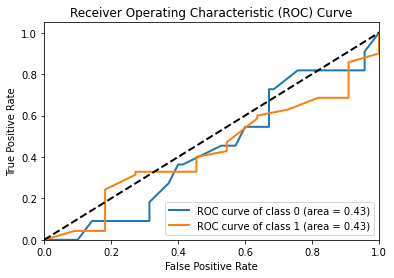

In [106]:

plt.figure()
for i in unique_classes:
    plt.plot(fpr[i], tpr[i], lw=2, label='ROC curve of class {0} (area = {1:0.2f})'.format(i, roc_auc[i]))
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [107]:
# natural spline
# Ensure X_category_3 is loaded as a NumPy array or Pandas DataFrame
# If X_category_3 is a Pandas DataFrame, convert it to a NumPy array
if isinstance(X_category_3, pd.DataFrame):
    X_category_3 = X_category_3.values

# Transform the new data using the fitted NaturalCubicSplineFeatures
X_category_3_transformed = ncs_features.transform(X_category_3)

# Predict labels for the transformed data using the trained logistic regression model
y_pred_category_3 = lr.predict(X_category_3_transformed)

# Output the prediction results
print("Predicted labels for X_category_3:", y_pred_category_3)


Predicted labels for X_category_3: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0]


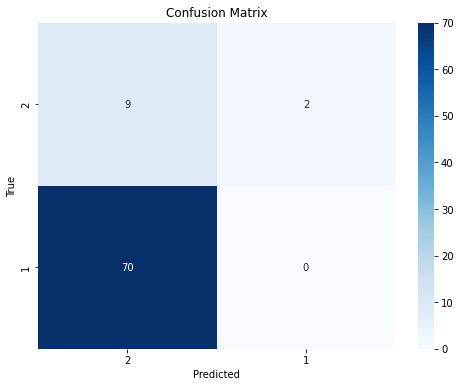

In [108]:
cm = confusion_matrix(category_3_data['confidence_2023'],y_pred_category_3 )
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[2, 1], yticklabels=[2, 1])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [109]:
print(classification_report(category_3_data['confidence_2023'],y_pred_category_3 ))

              precision    recall  f1-score   support

           0       0.11      0.82      0.20        11
           1       0.00      0.00      0.00        70

    accuracy                           0.11        81
   macro avg       0.06      0.41      0.10        81
weighted avg       0.02      0.11      0.03        81



Unique classes: [0, 1]
Class 0 AUC: 0.41
Class 1 AUC: 0.36


<function matplotlib.pyplot.show(close=None, block=None)>

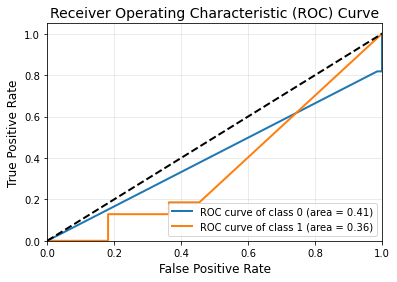

In [110]:
# Transform the test data and predict probabilities
X_category_3_transformed = ncs_features.transform(X_category_3)  # Transform the test data
y_prob_split = lr.predict_proba(X_category_3_transformed)  # Predicted probabilities


# Extract unique classes
unique_classes = sorted(np.unique(y_train_split))
print("Unique classes:", unique_classes)

# Initialize variables
class_to_index = {cls: idx for idx, cls in enumerate(unique_classes)}
fpr = {}
tpr = {}
roc_auc = {}

# Calculate ROC curve and AUC for each class
for cls in unique_classes:
    idx = class_to_index[cls]
    fpr[cls], tpr[cls], _ = roc_curve(category_3_data['confidence_2023'] == cls, y_prob_split[:, idx])
    roc_auc[cls] = auc(fpr[cls], tpr[cls])
    print(f"Class {cls} AUC: {roc_auc[cls]:.2f}")

# Plot ROC curve
plt.figure()

for cls in unique_classes:
    plt.plot(fpr[cls], tpr[cls], lw=2, label=f"ROC curve of class {cls} (area = {roc_auc[cls]:0.2f})")

# Plot the diagonal line
plt.plot([0, 1], [0, 1], 'k--', lw=2)

# Formatting the plot
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14)
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.show


In [111]:
print(X_category_3.shape)

(81, 4)


In [112]:
#gam
y_test_proba = gam_clf.predict_proba(X_category_3)
 
custom_threshold = 0.5
y_test_pred = (y_test_proba >= custom_threshold).astype(int)
accuracy = accuracy_score(category_3_data['confidence_2023'], y_test_pred)
print(y_test_pred)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 0 1 1 1 1 0 0 0 1 0 1 1 1 0 1 1 1 0 0
 1 1 0 0 0 0 1 1 1 1 1 1 0 1 1 1 1 1 1 1 0 1 1 1 1 0 1 1 0 1 1 0 1 1 0 0 1
 1 0 1 1 1 1 1]


/Users/wangyu/opt/anaconda3/lib/python3.9/site-packages/pygam/links.py:133: RuntimeWarning: overflow encountered in exp
  elp = np.exp(lp)
/Users/wangyu/opt/anaconda3/lib/python3.9/site-packages/pygam/links.py:134: RuntimeWarning: invalid value encountered in divide
  return dist.levels * elp / (elp + 1)


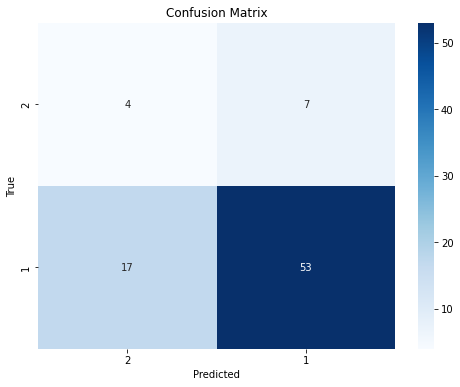

In [113]:
cm = confusion_matrix( category_3_data['confidence_2023'],y_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[2, 1], yticklabels=[2, 1])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [114]:
print("\nClassification Report:")
print(classification_report( category_3_data['confidence_2023'],y_test_pred))
lr_error_rate = error_rate(category_3_data['confidence_2023'], y_test_pred)
print(f'Logistic Regression Test Error Rate: {lr_error_rate*100:.1f}%')


Classification Report:
              precision    recall  f1-score   support

           0       0.19      0.36      0.25        11
           1       0.88      0.76      0.82        70

    accuracy                           0.70        81
   macro avg       0.54      0.56      0.53        81
weighted avg       0.79      0.70      0.74        81

Logistic Regression Test Error Rate: 29.6%


In [118]:
# # GAQQ
# X3 =X_category_3[category_3_data['confidence_2023'] == 1]
# X4 = X_category_3[category_3_data['confidence_2023']== 0]
# pred_result = classify(X1, X2, X3, X4, C_opt_r, delta_h_opt)
# y_hat = np.array(pred_result.rx2('y_hat'))
# error = pred_result.rx2('error')[0]
# rmse = pred_result.rx2('rmse')[0]
# est_label = np.array(pred_result.rx2('est_label'))
# y_pred=1-est_label

In [119]:
# cm = confusion_matrix(category_3_data['confidence_2023'],  y_pred)
# plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[2, 1], yticklabels=[2, 1])
# plt.xlabel("Predicted")
# plt.ylabel("True")
# plt.title("Confusion Matrix")
# plt.show()

In [ ]:
# print(classification_report(category_3_data['confidence_2023'], y_pred ))

In [117]:
##mars

In [121]:
# use predict() function in R to predict
predict = ro.r['predict']  # loading predict() from R
y_pred_r = predict(mars_model, X_category_3, type = "class")  # prediction
# transform matrix(in R) to numpy 
y_test_pred = np.array(y_pred_r) 




              precision    recall  f1-score   support

           0       0.19      0.45      0.26        11
           1       0.89      0.69      0.77        70

    accuracy                           0.65        81
   macro avg       0.54      0.57      0.52        81
weighted avg       0.79      0.65      0.70        81



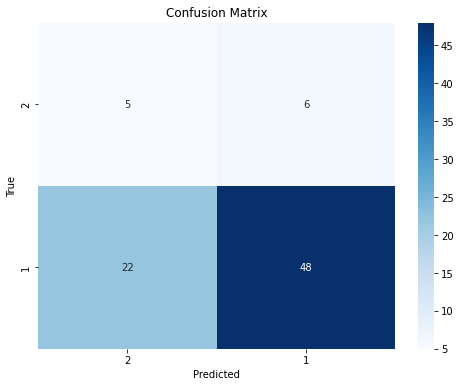

In [122]:
print(classification_report(category_3_data['confidence_2023'], y_test_pred))
cm = confusion_matrix(category_3_data['confidence_2023'], y_test_pred )
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[2, 1], yticklabels=[2, 1])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
print(accuracy_score(category_3_data['confidence_2023'], y_test_pred))